In [1]:
import pandas as pd
import numpy as np
import sqlite3
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Configura o caminho para o banco de dados
project_root = pathlib.Path("..") 
db_path = project_root / "banco de dados" / "crash_bot_historico.db"

print(f"Carregando dados de: {db_path}")

try:
    with sqlite3.connect(db_path) as conn:
        query = "SELECT timestamp, multiplicador FROM multiplicadores_historico ORDER BY timestamp ASC"
        df = pd.read_sql_query(query, conn, parse_dates=["timestamp"])
    
    df = df.set_index("timestamp").sort_index()
    multiplicadores = df['multiplicador'].tolist()
    print(f"Sucesso: {len(multiplicadores)} rodadas carregadas do banco de dados.")
    
    print("\nÚltimas 5 rodadas carregadas:")
    display(df.tail())

except Exception as e:
    print(f"Erro ao carregar dados: {e}")

Carregando dados de: ..\banco de dados\crash_bot_historico.db
Sucesso: 105281 rodadas carregadas do banco de dados.

Últimas 5 rodadas carregadas:


,multiplicador
timestamp,
2026-01-12 10:59:18.988372,5.82
2026-01-12 10:59:37.730203,1.53
2026-01-12 11:00:04.503964,5.64
2026-01-12 11:00:29.862974,2.88
2026-01-12 11:00:44.898111,1.09


In [2]:
# --- CÉLULA 2: DEFINIÇÃO DAS ESTRATÉGIAS ---

print("="*80)
print("🎰 COMPARAÇÃO DE ESTRATÉGIAS 1-2-4 (MARTINGALE)")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    DEFINIÇÃO DAS 3 ESTRATÉGIAS                               ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🔴 AGRESSIVA:                                                               ║
║     • Gatilho: 6 baixas consecutivas                                         ║
║     • Dobras: 4 (1-2-4-8) → Martingale até a 10ª baixa                       ║
║     • Quebra: 11+ baixas consecutivas                                        ║
║                                                                              ║
║  🟡 MODERADA:                                                                 ║
║     • Gatilho: 7 baixas consecutivas                                         ║
║     • Dobras: 4 (1-2-4-8) → Martingale até a 11ª baixa                       ║
║     • Quebra: 12+ baixas consecutivas                                        ║
║                                                                              ║
║  🟢 CONSERVADORA:                                                             ║
║     • Gatilho: 8 baixas consecutivas                                         ║
║     • Dobras: 4 (1-2-4-8) → Martingale até a 12ª baixa                       ║
║     • Quebra: 13+ baixas consecutivas                                        ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Todas usam:                                                                 ║
║     • Target: 1.99x                                                          ║
║     • Proporção Martingale: 1-2-4-8 (total = 15 partes)                      ║
║     • Taxa da casa: 1%                                                       ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

🎰 COMPARAÇÃO DE ESTRATÉGIAS 1-2-4 (MARTINGALE)

╔══════════════════════════════════════════════════════════════════════════════╗
║                    DEFINIÇÃO DAS 3 ESTRATÉGIAS                               ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🔴 AGRESSIVA:                                                               ║
║     • Gatilho: 6 baixas consecutivas                                         ║
║     • Dobras: 4 (1-2-4-8) → Martingale até a 10ª baixa                       ║
║     • Quebra: 11+ baixas consecutivas                                        ║
║                                                                              ║
║  🟡 MODERADA:                                                                 ║
║     • Gatilho: 7 baixas consecutivas                                         ║
║     • Dobras: 4 (1-2-4-8) → Martingale até a 11ª baixa      

In [3]:
# --- CÉLULA 3: FUNÇÃO DE SIMULAÇÃO GENÉRICA ---

def simular_estrategia_124(multiplicadores, banca=500, gatilho=6, max_dobras=4, target=1.99):
    """
    Simula estratégia Martingale 1-2-4-8 (ou menos dobras).
    
    Parâmetros:
    - gatilho: quantas baixas para entrar
    - max_dobras: quantas dobras no martingale (4 = 1-2-4-8)
    - target: multiplicador alvo
    
    Quebra se: gatilho + max_dobras baixas consecutivas
    """
    # Calcular proporções do Martingale
    # 1-2-4-8 = 15 partes total
    proporcoes = [1, 2, 4, 8][:max_dobras]
    total_proporcoes = sum(proporcoes)
    parte = banca / total_proporcoes
    
    dobras = {i+1: parte * p for i, p in enumerate(proporcoes)}
    
    # Variáveis de resultado
    lucro_total = 0
    quebras = 0
    wins = {i+1: 0 for i in range(max_dobras)}
    entradas = 0
    historico = [0]
    
    # Detalhes das quebras
    detalhes_quebras = []
    
    i = 0
    while i < len(multiplicadores):
        # Contar baixas consecutivas
        lows = 0
        j = i
        while j < len(multiplicadores) and multiplicadores[j] < 2.0:
            lows += 1
            j += 1
        
        # Se atingiu o gatilho, entra!
        if lows >= gatilho:
            entradas += 1
            entrada_pos = i + gatilho  # Posição da primeira aposta
            perdas = 0
            ganhou = False
            
            # Tentar cada dobra
            for dobra in range(1, max_dobras + 1):
                pos = entrada_pos + (dobra - 1)
                if pos >= len(multiplicadores):
                    break
                
                aposta = dobras[dobra]
                
                if multiplicadores[pos] >= target:
                    # GANHOU!
                    ganho = aposta * (target - 1) * 0.99  # 1% taxa
                    lucro_total += ganho - perdas
                    wins[dobra] += 1
                    ganhou = True
                    break
                else:
                    # Perdeu esta dobra
                    perdas += aposta
            
            if not ganhou:
                # QUEBROU!
                lucro_total -= banca
                quebras += 1
                detalhes_quebras.append({
                    'posicao': i,
                    'sequencia': lows,
                    'lucro_momento': lucro_total
                })
            
            historico.append(lucro_total)
        
        i = j if j > i else i + 1
    
    # Calcular métricas
    taxa_win = sum(wins.values()) / entradas * 100 if entradas > 0 else 0
    lucro_por_entrada = lucro_total / entradas if entradas > 0 else 0
    
    # Drawdown
    serie = pd.Series(historico)
    pico = serie.cummax()
    drawdown = serie - pico
    max_drawdown = drawdown.min()
    
    return {
        'lucro': lucro_total,
        'quebras': quebras,
        'wins': wins,
        'entradas': entradas,
        'taxa_win': taxa_win,
        'lucro_por_entrada': lucro_por_entrada,
        'max_drawdown': max_drawdown,
        'historico': historico,
        'detalhes_quebras': detalhes_quebras,
        'dobras_config': dobras
    }

print("✅ Função de simulação carregada!")

✅ Função de simulação carregada!


In [4]:
# --- CÉLULA 4: EXECUTAR SIMULAÇÕES ---

print("="*80)
print("⏳ Executando simulações...")
print("="*80)

BANCA = 500
TARGET = 1.99

# Simular as 3 estratégias
estrategias = {
    'AGRESSIVA': {'gatilho': 6, 'max_dobras': 4, 'cor': '#e74c3c', 'emoji': '🔴'},
    'MODERADA': {'gatilho': 7, 'max_dobras': 4, 'cor': '#f39c12', 'emoji': '🟡'},
    'CONSERVADORA': {'gatilho': 8, 'max_dobras': 4, 'cor': '#2ecc71', 'emoji': '🟢'}
}

resultados = {}

for nome, config in estrategias.items():
    print(f"\n{config['emoji']} Simulando {nome}...")
    print(f"   Gatilho: {config['gatilho']} baixas | Dobras: {config['max_dobras']} (1-2-4-8)")
    print(f"   Quebra se: {config['gatilho'] + config['max_dobras']}+ baixas consecutivas")
    
    res = simular_estrategia_124(
        multiplicadores,
        banca=BANCA,
        gatilho=config['gatilho'],
        max_dobras=config['max_dobras'],
        target=TARGET
    )
    res['config'] = config
    resultados[nome] = res
    
    print(f"   ✅ Entradas: {res['entradas']} | Quebras: {res['quebras']} | Lucro: R$ {res['lucro']:,.2f}")

print("\n" + "="*80)
print("✅ Simulações concluídas!")
print("="*80)

⏳ Executando simulações...

🔴 Simulando AGRESSIVA...
   Gatilho: 6 baixas | Dobras: 4 (1-2-4-8)
   Quebra se: 10+ baixas consecutivas
   ✅ Entradas: 1271 | Quebras: 50 | Lucro: R$ 14,057.59

🟡 Simulando MODERADA...
   Gatilho: 7 baixas | Dobras: 4 (1-2-4-8)
   Quebra se: 11+ baixas consecutivas
   ✅ Entradas: 592 | Quebras: 19 | Lucro: R$ 8,834.51

🟢 Simulando CONSERVADORA...
   Gatilho: 8 baixas | Dobras: 4 (1-2-4-8)
   Quebra se: 12+ baixas consecutivas
   ✅ Entradas: 274 | Quebras: 6 | Lucro: R$ 5,587.07

✅ Simulações concluídas!


In [5]:
# --- CÉLULA 5: TABELA COMPARATIVA DETALHADA ---

print("\n" + "="*80)
print("📊 COMPARAÇÃO DETALHADA DAS ESTRATÉGIAS")
print("="*80)

print(f"\nDados: {len(multiplicadores):,} rodadas | Banca: R$ {BANCA} | Target: {TARGET}x")

print("\n" + "-"*80)
print(f"{'MÉTRICA':<25} {'🔴 AGRESSIVA':>18} {'🟡 MODERADA':>18} {'🟢 CONSERVADORA':>18}")
print("-"*80)

# Configuração
print(f"{'Gatilho (baixas)':<25} {resultados['AGRESSIVA']['config']['gatilho']:>18} {resultados['MODERADA']['config']['gatilho']:>18} {resultados['CONSERVADORA']['config']['gatilho']:>18}")
print(f"{'Quebra se (baixas)':<25} {resultados['AGRESSIVA']['config']['gatilho'] + 4:>18} {resultados['MODERADA']['config']['gatilho'] + 4:>18} {resultados['CONSERVADORA']['config']['gatilho'] + 4:>18}")

print("-"*80)

# Resultados principais
print(f"{'Entradas':<25} {resultados['AGRESSIVA']['entradas']:>18,} {resultados['MODERADA']['entradas']:>18,} {resultados['CONSERVADORA']['entradas']:>18,}")
print(f"{'Vitórias':<25} {sum(resultados['AGRESSIVA']['wins'].values()):>18,} {sum(resultados['MODERADA']['wins'].values()):>18,} {sum(resultados['CONSERVADORA']['wins'].values()):>18,}")
print(f"{'Quebras':<25} {resultados['AGRESSIVA']['quebras']:>18} {resultados['MODERADA']['quebras']:>18} {resultados['CONSERVADORA']['quebras']:>18}")
print(f"{'Taxa de Vitória':<25} {resultados['AGRESSIVA']['taxa_win']:>17.2f}% {resultados['MODERADA']['taxa_win']:>17.2f}% {resultados['CONSERVADORA']['taxa_win']:>17.2f}%")

print("-"*80)

# Financeiro
print(f"{'💰 LUCRO TOTAL':<25} R$ {resultados['AGRESSIVA']['lucro']:>14,.2f} R$ {resultados['MODERADA']['lucro']:>14,.2f} R$ {resultados['CONSERVADORA']['lucro']:>14,.2f}")
print(f"{'Lucro por Entrada':<25} R$ {resultados['AGRESSIVA']['lucro_por_entrada']:>14,.2f} R$ {resultados['MODERADA']['lucro_por_entrada']:>14,.2f} R$ {resultados['CONSERVADORA']['lucro_por_entrada']:>14,.2f}")
print(f"{'Max Drawdown':<25} R$ {resultados['AGRESSIVA']['max_drawdown']:>14,.2f} R$ {resultados['MODERADA']['max_drawdown']:>14,.2f} R$ {resultados['CONSERVADORA']['max_drawdown']:>14,.2f}")

print("="*80)


📊 COMPARAÇÃO DETALHADA DAS ESTRATÉGIAS

Dados: 105,281 rodadas | Banca: R$ 500 | Target: 1.99x

--------------------------------------------------------------------------------
MÉTRICA                          🔴 AGRESSIVA         🟡 MODERADA     🟢 CONSERVADORA
--------------------------------------------------------------------------------
Gatilho (baixas)                           6                  7                  8
Quebra se (baixas)                        10                 11                 12
--------------------------------------------------------------------------------
Entradas                               1,271                592                274
Vitórias                               1,221                573                268
Quebras                                   50                 19                  6
Taxa de Vitória                       96.07%             96.79%             97.81%
-------------------------------------------------------------------------------

In [6]:
# --- CÉLULA 6: DISTRIBUIÇÃO DE VITÓRIAS POR DOBRA ---

print("\n" + "="*80)
print("📈 DISTRIBUIÇÃO DE VITÓRIAS POR DOBRA")
print("="*80)

for nome, res in resultados.items():
    config = res['config']
    print(f"\n{config['emoji']} {nome} (Gatilho: {config['gatilho']}, Quebra: {config['gatilho']+4}+)")
    print("-"*50)
    
    total_wins = sum(res['wins'].values())
    
    for dobra, qtd in res['wins'].items():
        baixa_num = config['gatilho'] + dobra - 1
        pct = qtd / res['entradas'] * 100 if res['entradas'] > 0 else 0
        pct_wins = qtd / total_wins * 100 if total_wins > 0 else 0
        
        aposta = res['dobras_config'][dobra]
        barra = '█' * int(pct_wins / 5)
        
        print(f"  Dobra {dobra} ({baixa_num}ª baixa): {qtd:>5} ({pct:>5.1f}%) {barra}")
    
    print(f"  {'─'*40}")
    print(f"  QUEBRAS ({config['gatilho']+4}+ baixas): {res['quebras']:>5} ({res['quebras']/res['entradas']*100:.2f}%)")


📈 DISTRIBUIÇÃO DE VITÓRIAS POR DOBRA

🔴 AGRESSIVA (Gatilho: 6, Quebra: 10+)
--------------------------------------------------
  Dobra 1 (6ª baixa):   682 ( 53.7%) ███████████
  Dobra 2 (7ª baixa):   317 ( 24.9%) █████
  Dobra 3 (8ª baixa):   154 ( 12.1%) ██
  Dobra 4 (9ª baixa):    68 (  5.4%) █
  ────────────────────────────────────────
  QUEBRAS (10+ baixas):    50 (3.93%)

🟡 MODERADA (Gatilho: 7, Quebra: 11+)
--------------------------------------------------
  Dobra 1 (7ª baixa):   318 ( 53.7%) ███████████
  Dobra 2 (8ª baixa):   154 ( 26.0%) █████
  Dobra 3 (9ª baixa):    70 ( 11.8%) ██
  Dobra 4 (10ª baixa):    31 (  5.2%) █
  ────────────────────────────────────────
  QUEBRAS (11+ baixas):    19 (3.21%)

🟢 CONSERVADORA (Gatilho: 8, Quebra: 12+)
--------------------------------------------------
  Dobra 1 (8ª baixa):   154 ( 56.2%) ███████████
  Dobra 2 (9ª baixa):    70 ( 25.5%) █████
  Dobra 3 (10ª baixa):    31 ( 11.3%) ██
  Dobra 4 (11ª baixa):    13 (  4.7%) 
  ───────────

In [7]:
# --- CÉLULA 7: ANÁLISE DAS QUEBRAS ---

print("\n" + "="*80)
print("💀 ANÁLISE DETALHADA DAS QUEBRAS")
print("="*80)

for nome, res in resultados.items():
    config = res['config']
    print(f"\n{config['emoji']} {nome}:")
    
    if res['quebras'] == 0:
        print(f"   ✅ NENHUMA QUEBRA! Estratégia 100% segura neste período.")
    else:
        print(f"   Total de quebras: {res['quebras']}")
        print(f"   Prejuízo total com quebras: R$ {res['quebras'] * BANCA:,.2f}")
        
        if res['detalhes_quebras']:
            print(f"\n   Detalhes:")
            for i, q in enumerate(res['detalhes_quebras'], 1):
                print(f"   {i}. Sequência de {q['sequencia']} baixas | Lucro no momento: R$ {q['lucro_momento']:,.2f}")


💀 ANÁLISE DETALHADA DAS QUEBRAS

🔴 AGRESSIVA:
   Total de quebras: 50
   Prejuízo total com quebras: R$ 25,000.00

   Detalhes:
   1. Sequência de 11 baixas | Lucro no momento: R$ -376.62
   2. Sequência de 10 baixas | Lucro no momento: R$ 1,459.21
   3. Sequência de 10 baixas | Lucro no momento: R$ 1,604.65
   4. Sequência de 10 baixas | Lucro no momento: R$ 2,227.53
   5. Sequência de 10 baixas | Lucro no momento: R$ 1,856.22
   6. Sequência de 10 baixas | Lucro no momento: R$ 3,243.95
   7. Sequência de 11 baixas | Lucro no momento: R$ 3,280.77
   8. Sequência de 11 baixas | Lucro no momento: R$ 3,652.25
   9. Sequência de 11 baixas | Lucro no momento: R$ 3,665.02
   10. Sequência de 10 baixas | Lucro no momento: R$ 3,385.75
   11. Sequência de 10 baixas | Lucro no momento: R$ 2,982.43
   12. Sequência de 12 baixas | Lucro no momento: R$ 2,482.43
   13. Sequência de 10 baixas | Lucro no momento: R$ 2,013.11
   14. Sequência de 12 baixas | Lucro no momento: R$ 2,471.32
   15. Sequên

C:\Users\jose\AppData\Local\Temp\ipykernel_24552\1608075813.py:66: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jose\AppData\Local\Temp\ipykernel_24552\1608075813.py:66: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jose\AppData\Local\Temp\ipykernel_24552\1608075813.py:66: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jose\AppData\Local\Temp\ipykernel_24552\1608075813.py:67: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('01_comparacao_estrategias_124.png', dpi=150, bbox_inches='tight')
C:\Users\jose\AppData\Local\Temp\ipykernel_24552\1608075813.py:67: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('01_comparacao_estrategias_124.png', dpi=150, bbox_inches='tight')
C:\Users\jose\App

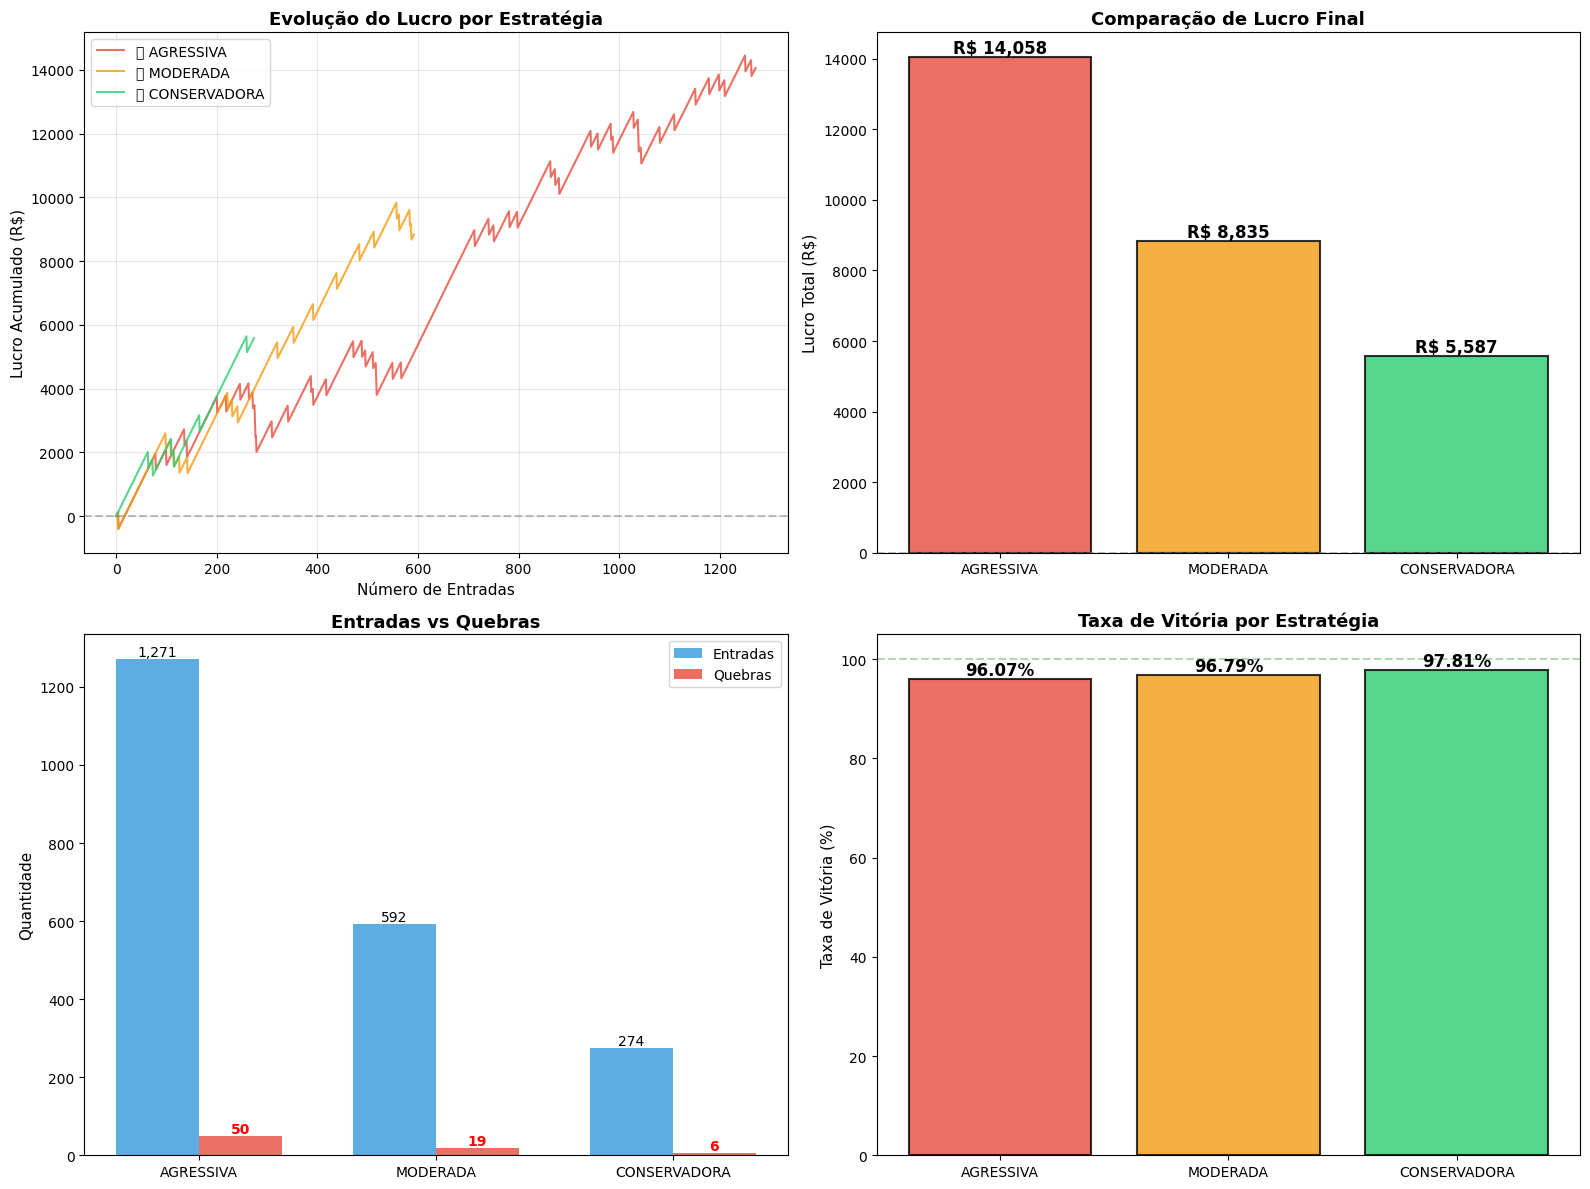


📁 Gráfico salvo: 01_comparacao_estrategias_124.png


In [8]:
# --- CÉLULA 8: GRÁFICO DE EVOLUÇÃO DO LUCRO ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Evolução do lucro
ax1 = axes[0, 0]
for nome, res in resultados.items():
    ax1.plot(res['historico'], label=f"{res['config']['emoji']} {nome}", 
             color=res['config']['cor'], linewidth=1.5, alpha=0.8)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Número de Entradas', fontsize=11)
ax1.set_ylabel('Lucro Acumulado (R$)', fontsize=11)
ax1.set_title('Evolução do Lucro por Estratégia', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Comparação de Lucro Final
ax2 = axes[0, 1]
nomes = list(resultados.keys())
lucros = [resultados[n]['lucro'] for n in nomes]
cores = [resultados[n]['config']['cor'] for n in nomes]
bars = ax2.bar(nomes, lucros, color=cores, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Lucro Total (R$)', fontsize=11)
ax2.set_title('Comparação de Lucro Final', fontsize=13, fontweight='bold')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
for bar, lucro in zip(bars, lucros):
    va = 'bottom' if lucro >= 0 else 'top'
    ax2.annotate(f'R$ {lucro:,.0f}', xy=(bar.get_x() + bar.get_width()/2, lucro),
                 ha='center', va=va, fontsize=12, fontweight='bold')

# 3. Comparação de Entradas e Quebras
ax3 = axes[1, 0]
x = np.arange(len(nomes))
width = 0.35
entradas = [resultados[n]['entradas'] for n in nomes]
quebras = [resultados[n]['quebras'] for n in nomes]

bars1 = ax3.bar(x - width/2, entradas, width, label='Entradas', color='#3498db', alpha=0.8)
bars2 = ax3.bar(x + width/2, quebras, width, label='Quebras', color='#e74c3c', alpha=0.8)

ax3.set_ylabel('Quantidade', fontsize=11)
ax3.set_title('Entradas vs Quebras', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(nomes)
ax3.legend()

for bar, val in zip(bars1, entradas):
    ax3.annotate(f'{val:,}', xy=(bar.get_x() + bar.get_width()/2, val),
                 ha='center', va='bottom', fontsize=10)
for bar, val in zip(bars2, quebras):
    ax3.annotate(f'{val}', xy=(bar.get_x() + bar.get_width()/2, val),
                 ha='center', va='bottom', fontsize=10, color='red', fontweight='bold')

# 4. Taxa de Vitória
ax4 = axes[1, 1]
taxas = [resultados[n]['taxa_win'] for n in nomes]
bars = ax4.bar(nomes, taxas, color=cores, alpha=0.8, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Taxa de Vitória (%)', fontsize=11)
ax4.set_title('Taxa de Vitória por Estratégia', fontsize=13, fontweight='bold')
ax4.set_ylim(0, 105)
ax4.axhline(y=100, color='green', linestyle='--', alpha=0.3)
for bar, taxa in zip(bars, taxas):
    ax4.annotate(f'{taxa:.2f}%', xy=(bar.get_x() + bar.get_width()/2, taxa),
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('01_comparacao_estrategias_124.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📁 Gráfico salvo: 01_comparacao_estrategias_124.png")

C:\Users\jose\AppData\Local\Temp\ipykernel_24552\3246155351.py:36: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jose\AppData\Local\Temp\ipykernel_24552\3246155351.py:36: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jose\AppData\Local\Temp\ipykernel_24552\3246155351.py:36: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jose\AppData\Local\Temp\ipykernel_24552\3246155351.py:37: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('02_distribuicao_vitorias_124.png', dpi=150, bbox_inches='tight')
C:\Users\jose\AppData\Local\Temp\ipykernel_24552\3246155351.py:37: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('02_distribuicao_vitorias_124.png', dpi=150, bbox_inches='tight')
C:\Users\jose\AppDa

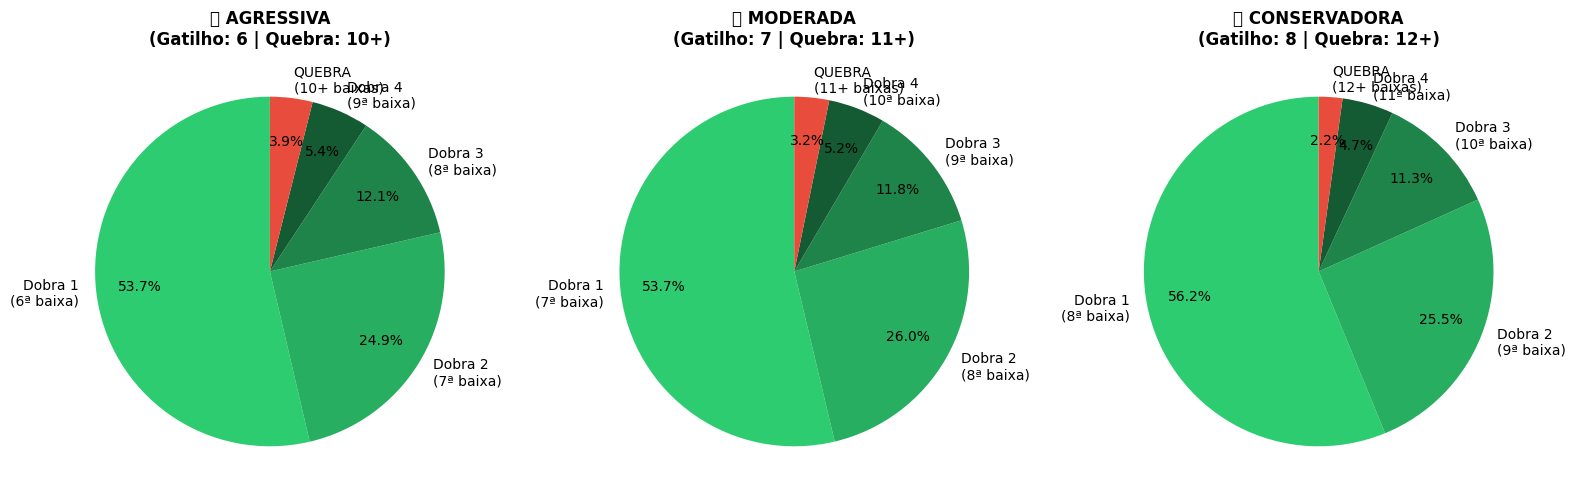


📁 Gráfico salvo: 02_distribuicao_vitorias_124.png


In [9]:
# --- CÉLULA 9: GRÁFICO DE DISTRIBUIÇÃO DE VITÓRIAS ---

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (nome, res) in enumerate(resultados.items()):
    ax = axes[idx]
    config = res['config']
    
    # Dados
    dobras = list(res['wins'].keys())
    valores = list(res['wins'].values())
    valores.append(res['quebras'])  # Adicionar quebras
    labels = [f"Dobra {d}\n({config['gatilho']+d-1}ª baixa)" for d in dobras]
    labels.append(f"QUEBRA\n({config['gatilho']+4}+ baixas)")
    
    cores_pizza = ['#2ecc71', '#27ae60', '#1e8449', '#145a32', '#e74c3c']
    
    # Só mostrar se tiver valor
    valores_filtrados = []
    labels_filtrados = []
    cores_filtradas = []
    
    for v, l, c in zip(valores, labels, cores_pizza):
        if v > 0:
            valores_filtrados.append(v)
            labels_filtrados.append(l)
            cores_filtradas.append(c)
    
    wedges, texts, autotexts = ax.pie(valores_filtrados, labels=labels_filtrados, 
                                       colors=cores_filtradas, autopct='%1.1f%%',
                                       startangle=90, pctdistance=0.75)
    
    ax.set_title(f"{config['emoji']} {nome}\n(Gatilho: {config['gatilho']} | Quebra: {config['gatilho']+4}+)", 
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('02_distribuicao_vitorias_124.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📁 Gráfico salvo: 02_distribuicao_vitorias_124.png")

In [10]:
# --- CÉLULA 10: ANÁLISE DE RISCO/RETORNO ---

print("\n" + "="*80)
print("📊 ANÁLISE DE RISCO/RETORNO")
print("="*80)

print(f"\n{'MÉTRICA':<30} {'🔴 AGRESSIVA':>15} {'🟡 MODERADA':>15} {'🟢 CONSERVADORA':>15}")
print("-"*80)

for nome, res in resultados.items():
    # Calcular métricas adicionais
    serie = pd.Series(res['historico'])
    retornos = serie.diff().dropna()
    
    res['volatilidade'] = retornos.std()
    res['sharpe'] = retornos.mean() / retornos.std() if retornos.std() > 0 else 0
    res['profit_factor'] = abs(res['lucro'] + res['quebras'] * BANCA) / (res['quebras'] * BANCA) if res['quebras'] > 0 else float('inf')

print(f"{'Lucro Total':<30} R$ {resultados['AGRESSIVA']['lucro']:>12,.2f} R$ {resultados['MODERADA']['lucro']:>12,.2f} R$ {resultados['CONSERVADORA']['lucro']:>12,.2f}")
print(f"{'Entradas':<30} {resultados['AGRESSIVA']['entradas']:>15,} {resultados['MODERADA']['entradas']:>15,} {resultados['CONSERVADORA']['entradas']:>15,}")
print(f"{'Quebras':<30} {resultados['AGRESSIVA']['quebras']:>15} {resultados['MODERADA']['quebras']:>15} {resultados['CONSERVADORA']['quebras']:>15}")
print(f"{'Taxa de Vitória':<30} {resultados['AGRESSIVA']['taxa_win']:>14.2f}% {resultados['MODERADA']['taxa_win']:>14.2f}% {resultados['CONSERVADORA']['taxa_win']:>14.2f}%")
print("-"*80)
print(f"{'Lucro/Entrada':<30} R$ {resultados['AGRESSIVA']['lucro_por_entrada']:>12,.2f} R$ {resultados['MODERADA']['lucro_por_entrada']:>12,.2f} R$ {resultados['CONSERVADORA']['lucro_por_entrada']:>12,.2f}")
print(f"{'Max Drawdown':<30} R$ {resultados['AGRESSIVA']['max_drawdown']:>12,.2f} R$ {resultados['MODERADA']['max_drawdown']:>12,.2f} R$ {resultados['CONSERVADORA']['max_drawdown']:>12,.2f}")
print(f"{'Volatilidade':<30} R$ {resultados['AGRESSIVA']['volatilidade']:>12,.2f} R$ {resultados['MODERADA']['volatilidade']:>12,.2f} R$ {resultados['CONSERVADORA']['volatilidade']:>12,.2f}")
print(f"{'Sharpe Ratio':<30} {resultados['AGRESSIVA']['sharpe']:>15.3f} {resultados['MODERADA']['sharpe']:>15.3f} {resultados['CONSERVADORA']['sharpe']:>15.3f}")


📊 ANÁLISE DE RISCO/RETORNO

MÉTRICA                            🔴 AGRESSIVA      🟡 MODERADA  🟢 CONSERVADORA
--------------------------------------------------------------------------------
Lucro Total                    R$    14,057.59 R$     8,834.51 R$     5,587.07
Entradas                                 1,271             592             274
Quebras                                     50              19               6
Taxa de Vitória                         96.07%          96.79%          97.81%
--------------------------------------------------------------------------------
Lucro/Entrada                  R$        11.06 R$        14.92 R$        20.39
Max Drawdown                   R$    -2,151.91 R$    -1,257.05 R$      -873.96
Volatilidade                   R$       103.47 R$        93.85 R$        78.01
Sharpe Ratio                             0.107           0.159           0.261


In [11]:
# --- CÉLULA 11: CONCLUSÃO E RECOMENDAÇÃO ---

print("\n" + "="*80)
print("🏆 CONCLUSÃO E RECOMENDAÇÃO")
print("="*80)

# Encontrar a melhor
melhor_lucro = max(resultados.items(), key=lambda x: x[1]['lucro'])
melhor_segura = min(resultados.items(), key=lambda x: x[1]['quebras'])
melhor_sharpe = max(resultados.items(), key=lambda x: x[1]['sharpe'])

print(f"""
📊 ANÁLISE DOS RESULTADOS:

🔴 AGRESSIVA (Gatilho 6, Quebra 10+):
   • Mais entradas ({resultados['AGRESSIVA']['entradas']:,})
   • Maior exposição ao risco
   • Lucro: R$ {resultados['AGRESSIVA']['lucro']:,.2f}
   • Quebras: {resultados['AGRESSIVA']['quebras']}

🟡 MODERADA (Gatilho 7, Quebra 11+):
   • Equilíbrio entre risco e retorno
   • Entradas: {resultados['MODERADA']['entradas']:,}
   • Lucro: R$ {resultados['MODERADA']['lucro']:,.2f}
   • Quebras: {resultados['MODERADA']['quebras']}

🟢 CONSERVADORA (Gatilho 8, Quebra 12+):
   • Menos entradas ({resultados['CONSERVADORA']['entradas']:,})
   • Menor exposição ao risco
   • Lucro: R$ {resultados['CONSERVADORA']['lucro']:,.2f}
   • Quebras: {resultados['CONSERVADORA']['quebras']}

{'─'*70}

🏆 RANKINGS:

   💰 MAIOR LUCRO: {melhor_lucro[0]} (R$ {melhor_lucro[1]['lucro']:,.2f})
   
   🛡️ MAIS SEGURA: {melhor_segura[0]} ({melhor_segura[1]['quebras']} quebras)
   
   📈 MELHOR SHARPE: {melhor_sharpe[0]} ({melhor_sharpe[1]['sharpe']:.3f})

{'─'*70}

💡 RECOMENDAÇÃO FINAL:
""")

# Determinar recomendação baseada nos dados
if resultados['CONSERVADORA']['quebras'] == 0:
    print("   ✅ CONSERVADORA é a única com ZERO quebras!")
    print(f"   ✅ Lucro de R$ {resultados['CONSERVADORA']['lucro']:,.2f} com 100% de segurança")
elif resultados['CONSERVADORA']['lucro'] > 0 and resultados['CONSERVADORA']['quebras'] <= 2:
    print("   ✅ CONSERVADORA oferece melhor relação risco/retorno")
elif resultados['AGRESSIVA']['lucro'] > resultados['CONSERVADORA']['lucro'] * 1.5:
    print("   ⚠️ AGRESSIVA tem lucro significativamente maior, mas com mais risco")
    print("   💡 Considere MODERADA como meio-termo")
else:
    print("   💡 Escolha baseada no seu perfil de risco:")
    print("      • Conservador → Use CONSERVADORA")
    print("      • Equilibrado → Use MODERADA")
    print("      • Agressivo → Use AGRESSIVA")


🏆 CONCLUSÃO E RECOMENDAÇÃO

📊 ANÁLISE DOS RESULTADOS:

🔴 AGRESSIVA (Gatilho 6, Quebra 10+):
   • Mais entradas (1,271)
   • Maior exposição ao risco
   • Lucro: R$ 14,057.59
   • Quebras: 50

🟡 MODERADA (Gatilho 7, Quebra 11+):
   • Equilíbrio entre risco e retorno
   • Entradas: 592
   • Lucro: R$ 8,834.51
   • Quebras: 19

🟢 CONSERVADORA (Gatilho 8, Quebra 12+):
   • Menos entradas (274)
   • Menor exposição ao risco
   • Lucro: R$ 5,587.07
   • Quebras: 6

──────────────────────────────────────────────────────────────────────

🏆 RANKINGS:

   💰 MAIOR LUCRO: AGRESSIVA (R$ 14,057.59)
   
   🛡️ MAIS SEGURA: CONSERVADORA (6 quebras)
   
   📈 MELHOR SHARPE: CONSERVADORA (0.261)

──────────────────────────────────────────────────────────────────────

💡 RECOMENDAÇÃO FINAL:

   ⚠️ AGRESSIVA tem lucro significativamente maior, mas com mais risco
   💡 Considere MODERADA como meio-termo


In [12]:
# --- CÉLULA 12: SALVAR RESULTADOS ---

# Criar DataFrame com resultados
df_resultados = pd.DataFrame([
    {
        'Estrategia': nome,
        'Gatilho': res['config']['gatilho'],
        'Quebra_Se': res['config']['gatilho'] + 4,
        'Entradas': res['entradas'],
        'Vitorias': sum(res['wins'].values()),
        'Quebras': res['quebras'],
        'Taxa_Vitoria': res['taxa_win'],
        'Lucro_Total': res['lucro'],
        'Lucro_Por_Entrada': res['lucro_por_entrada'],
        'Max_Drawdown': res['max_drawdown'],
        'Volatilidade': res['volatilidade'],
        'Sharpe_Ratio': res['sharpe']
    }
    for nome, res in resultados.items()
])

print("\n📊 Tabela de Resultados:")
display(df_resultados)

# Salvar
df_resultados.to_csv('resultados_comparacao_124.csv', index=False)
print("\n📁 Resultados salvos: resultados_comparacao_124.csv")


📊 Tabela de Resultados:


,Estrategia,Gatilho,Quebra_Se,Entradas,Vitorias,Quebras,Taxa_Vitoria,Lucro_Total,Lucro_Por_Entrada,Max_Drawdown,Volatilidade,Sharpe_Ratio
0,AGRESSIVA,6,10,1271,1221,50,96.066090,14057.586667,11.060257,-2151.906667,103.465727,0.106898
1,MODERADA,7,11,592,573,19,96.790541,8834.513333,14.923164,-1257.046667,93.851343,0.159009
2,CONSERVADORA,8,12,274,268,6,97.810219,5587.073333,20.390779,-873.963333,78.014376,0.261372



📁 Resultados salvos: resultados_comparacao_124.csv
